# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [1]:
# DO NOT CHANGE

import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [2]:
bandit0 = BanditProblem(0)

In [3]:
bandit0.get_num_arms()

3

In [4]:
bandit0.get_reward(arm=0)

1.8255111545554434

In [5]:
# YOUR CHANGES HERE

# Sample each arm many times to see what kind of numbers the rewards are.
num_arms = bandit0.get_num_arms()
num_samples = 3000

samples = {
    arm: np.array([bandit0.get_reward(arm) for _ in range(num_samples)])
    for arm in range(num_arms)
}

for arm in range(num_arms):
    x = samples[arm]
    print(
        f"arm {arm}:"
        f" min={x.min():.4f}"
        f" mean={x.mean():.4f}"
        f" max={x.max():.4f}"
        f" distinct_values={len(np.unique(x))}"
        f" fraction_exactly_zero={np.mean(x == 0):.4f}"
        f" fraction_in_zero_one_set={np.mean(np.isin(x, [0, 1])):.4f}"
    )


arm 0: min=0.0000 mean=0.8168 max=6.7825 distinct_values=2500 fraction_exactly_zero=0.1670 fraction_in_zero_one_set=0.1670
arm 1: min=0.0000 mean=0.6202 max=3.9337 distinct_values=2238 fraction_exactly_zero=0.2543 fraction_in_zero_one_set=0.2543
arm 2: min=0.0000 mean=0.9142 max=4.6669 distinct_values=2685 fraction_exactly_zero=0.1053 fraction_in_zero_one_set=0.1053


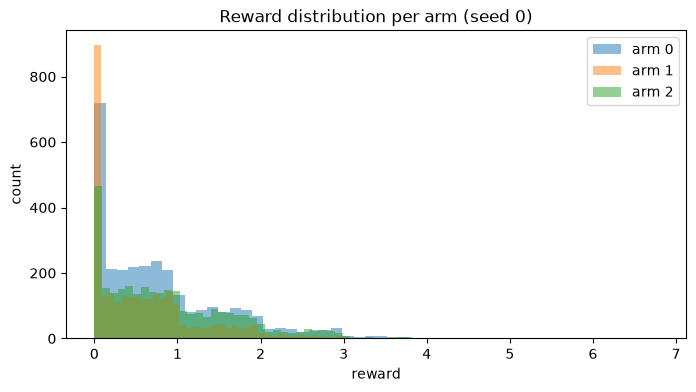

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
for arm in range(num_arms):
    ax.hist(samples[arm], bins=50, alpha=0.5, label=f"arm {arm}")
ax.set_xlabel("reward")
ax.set_ylabel("count")
ax.set_title("Reward distribution per arm (seed 0)")
ax.legend()
plt.show()


Observations from the histogram and the summary statistics:

* Rewards are continuous, non-negative real numbers spread over roughly 0 to 7, not 0/1 successes.
* Each arm has a spike of probability mass at exactly 0 (the binomial draw came up 0), and the rest is spread smoothly over positive values.
* There is no known upper bound on the reward, and the observed maximum differs by arm.

So the rewards are real-valued and unbounded above rather than Bernoulli or bounded in [0, 1].


Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week.
Write a file "algorithm-choice.txt" that states your choice and give a single sentence justifying your choice and rejecting the alternatives.
Keep your explanation concise; you should be able to justify your choice solely based on the type of numbers observed, and whether those match the bandit algorithms that you have learned.

In [7]:
# YOUR CHANGES HERE

algorithm_choice = """epsilon-greedy

The rewards are continuous non-negative real numbers with no known upper bound (roughly 0 to 7 here) rather than 0/1 successes, so Thompson sampling with a beta-Bernoulli model does not apply and UCB1's assumption of rewards bounded in [0, 1] is violated, while epsilon-greedy only needs sample means and works with arbitrary real-valued rewards.
"""

with open("algorithm-choice.txt", "w") as f:
    f.write(algorithm_choice)

print(algorithm_choice)


epsilon-greedy

The rewards are continuous non-negative real numbers with no known upper bound (roughly 0 to 7 here) rather than 0/1 successes, so Thompson sampling with a beta-Bernoulli model does not apply and UCB1's assumption of rewards bounded in [0, 1] is violated, while epsilon-greedy only needs sample means and works with arbitrary real-valued rewards.



## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2026.

In [8]:
# YOUR CHANGES HERE

def epsilon_greedy(bandit, num_steps=1000, epsilon=0.1, seed=704):
    """Run epsilon-greedy on a bandit and return the actions taken and rewards seen."""
    num_arms = bandit.get_num_arms()

    # Separate rng for the algorithm's own coin flips so the bandit's stream is untouched.
    chooser = np.random.default_rng(seed)

    counts = np.zeros(num_arms, dtype=int)
    totals = np.zeros(num_arms)
    actions = []
    rewards = []

    for t in range(num_steps):
        if t < num_arms:
            action = t  # pull each arm once so every mean estimate starts defined
        elif chooser.uniform() < epsilon:
            action = int(chooser.integers(num_arms))  # explore
        else:
            action = int(np.argmax(totals / np.maximum(counts, 1)))  # exploit

        reward = bandit.get_reward(action)

        counts[action] += 1
        totals[action] += reward
        actions.append(action)
        rewards.append(reward)

    return np.array(actions), np.array(rewards)


NUM_STEPS = 1000
EPSILON = 0.1

bandit2026 = BanditProblem(2026)
actions, rewards = epsilon_greedy(bandit2026, num_steps=NUM_STEPS, epsilon=EPSILON)

print("actions taken:", len(actions))
print("times each arm was pulled:", np.bincount(actions, minlength=bandit2026.get_num_arms()))
print("total reward:", rewards.sum())


actions taken: 1000
times each arm was pulled: [942  33  25]
total reward: 1157.4794450857637


Write a file "history.tsv" with columns action and reward in the order that the actions were taken.

In [9]:
# YOUR CHANGES HERE

import pandas as pd

history = pd.DataFrame({"action": actions, "reward": rewards})
history.to_csv("history.tsv", sep="\t", index=False)

history.head()


,action,reward
0,0,3.162073
1,1,0.177353
2,2,0.298303
3,0,2.759550
4,0,1.505464


Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [10]:
# YOUR CHANGES HERE

actions_df = (
    history.groupby("action")["reward"]
    .agg(min_reward="min", mean_reward="mean", max_reward="max")
    .reindex(range(bandit2026.get_num_arms()))
    .reset_index()
)

actions_df.to_csv("actions.tsv", sep="\t", index=False)

actions_df


,action,min_reward,mean_reward,max_reward
0,0,0.0,1.215509,6.564312
1,1,0.0,0.227831,1.585987
2,2,0.0,0.198047,0.937254


Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Estimate the regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

These estimates should be based on your previous action statistics; you should not use the true action values from the bandit code.

In [11]:
# YOUR CHANGES HERE

# Estimated expected reward per arm, from part 3 only (no true values from the bandit code).
mean_rewards = actions_df.set_index("action")["mean_reward"]
best_mean = mean_rewards.max()
num_arms = len(mean_rewards)

# Regret over 1000 actions = 1000 * (best estimated mean) - expected total reward of the strategy.
strategies = {}

# uniform: each arm is equally likely, so the expected reward per step is the average of the means.
strategies["uniform"] = NUM_STEPS * (best_mean - mean_rewards.mean())

# just-i: every step earns the estimated mean of arm i.
for arm in range(num_arms):
    strategies[f"just-{arm}"] = NUM_STEPS * (best_mean - mean_rewards[arm])

# actual: the epsilon-greedy run from part 2, charged the estimated mean of whichever arm it pulled.
counts = history["action"].value_counts().reindex(range(num_arms), fill_value=0)
strategies["actual"] = NUM_STEPS * best_mean - float((counts * mean_rewards).sum())

for name, regret in strategies.items():
    print(f"{name}: {regret:.4f}")


uniform: 668.3802
just-0: 0.0000
just-1: 987.6784
just-2: 1017.4623
actual: 58.0299


Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [12]:
# YOUR CHANGES HERE

strategies_df = pd.DataFrame(
    {"strategy": list(strategies.keys()), "regret": list(strategies.values())}
)
strategies_df.to_csv("strategies.tsv", sep="\t", index=False)

strategies_df


,strategy,regret
0,uniform,668.380236
1,just-0,0.000000
2,just-1,987.678387
3,just-2,1017.462320
4,actual,58.029945


Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


In [13]:
# YOUR CHANGES HERE

acknowledgments = """Libraries used: numpy (bandit code and array math), pandas (building and writing
the TSV files), and matplotlib (histogram of the reward distribution in part 1).

Generative AI: I used Claude Code (Anthropic's command line coding assistant) to help write,
run, and check the code in this notebook.
Transcript: [ADD LINK TO YOUR TRANSCRIPT HERE]

No other outside sources or help.
"""

with open("acknowledgments.txt", "w") as f:
    f.write(acknowledgments)

print(acknowledgments)


Libraries used: numpy (bandit code and array math), pandas (building and writing
the TSV files), and matplotlib (histogram of the reward distribution in part 1).

Generative AI: I used Claude Code (Anthropic's command line coding assistant) to help write,
run, and check the code in this notebook.
Transcript: [ADD LINK TO YOUR TRANSCRIPT HERE]

No other outside sources or help.



Submit "acknowledgments.txt" in Gradescope.

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.